# Model Evaluation and Comparison for Affect Recognition
This notebook evaluates and compares multiple saved models on both categorical (expression) and continuous (valence/arousal) tasks.

## 1. Import Libraries and Setup

In [93]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import random
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms as T

# Metrics for categorical classification
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, 
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)

# Metrics for continuous domain
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
import krippendorff

print("All libraries imported successfully!")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

All libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True


In [94]:
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration and Dataset Classes

In [95]:
class Config:
    # Dataset paths - MODIFY THESE PATHS ACCORDING TO YOUR SETUP
    DATASET_ROOT = "/kaggle/input/arousal-valence-dataset/Dataset/Dataset/"  # Change this to your dataset path
    IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
    ANNOTATIONS_DIR = os.path.join(DATASET_ROOT, "annotations")
    
    # Model parameters
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    
    # Expression labels
    EXPRESSION_LABELS = {
        0: "Neutral", 1: "Happy", 2: "Sad", 3: "Surprise", 
        4: "Fear", 5: "Disgust", 6: "Anger", 7: "Contempt"
    }
    
    NUM_CLASSES = 8

config = Config()

@dataclass
class SampleIndex:
    sample_id: str
    image_path: str
    exp_path: str
    val_path: str
    aro_path: str

def _id_to_paths(sample_id: str) -> SampleIndex:
    """Build file paths for a given sample id."""
    img_path = os.path.join(config.IMAGES_DIR, f"{sample_id}.jpg")
    exp_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_exp.npy")
    val_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_val.npy")
    aro_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_aro.npy")
    return SampleIndex(sample_id, img_path, exp_path, val_path, aro_path)

def build_index() -> List[SampleIndex]:
    """Scan dataset folders and build a valid sample index."""
    ids = []
    for name in os.listdir(config.IMAGES_DIR):
        if not name.lower().endswith(".jpg"):
            continue
        sample_id = os.path.splitext(name)[0]
        idx = _id_to_paths(sample_id)
        if (os.path.exists(idx.exp_path) and 
            os.path.exists(idx.val_path) and 
            os.path.exists(idx.aro_path)):
            ids.append(sample_id)
    
    ids.sort(key=lambda x: int(x) if x.isdigit() else x)
    return [_id_to_paths(i) for i in ids]

In [96]:
class AffectDataset(Dataset):
    def __init__(self, indices: List[SampleIndex], transform=None):
        self.indices = indices
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        entry = self.indices[idx]

        # Load image
        img = Image.open(entry.image_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        # Load annotations
        exp = np.load(entry.exp_path).astype(np.int64)
        if exp.ndim:
            exp = int(exp.reshape(-1)[0])
        else:
            exp = int(exp)
            
        val = float(np.load(entry.val_path).reshape(-1)[0])
        aro = float(np.load(entry.aro_path).reshape(-1)[0])

        exp = torch.tensor(exp, dtype=torch.long)
        target_reg = torch.tensor([val, aro], dtype=torch.float32)

        return {
            "image": img,
            "exp": exp,
            "reg": target_reg,
            "id": entry.sample_id,
        }

def get_eval_transforms():
    """Data preprocessing for evaluation."""
    return transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

## 3. Model Architectures

In [97]:
class DualHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        self.cls = nn.Linear(in_features, num_classes)
        self.reg = nn.Linear(in_features, 2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Classification and regression heads."""
        logits = self.cls(x)
        reg = torch.tanh(self.reg(x))
        return logits, reg

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for channel attention."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class EnhancedDualHead(nn.Module):
    """Enhanced dual head with better feature processing."""
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        hidden_dim = 1024
        
        # Shared feature processing
        self.shared = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4)  
        )
        
        # Classification head
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
        # Regression head
        self.reg = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 2)
        )
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        shared_features = self.shared(x)
        logits = self.cls(shared_features)
        reg = torch.tanh(self.reg(shared_features))
        return logits, reg

class SimpleCNN(nn.Module):
    """A simple custom CNN with SE + dual pooling + dual head."""
    def __init__(self, num_classes: int = config.NUM_CLASSES):
        super().__init__()

        # Feature extractor
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.se_block = SEBlock(128)
        self.pool_avg = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_max = nn.AdaptiveMaxPool2d((1, 1))

        feature_dim = 128 * 2
        self.feature_enhance = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        self.head = EnhancedDualHead(256)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.se_block(x)

        avg_pool = self.pool_avg(x)
        max_pool = self.pool_max(x)

        x = torch.cat([avg_pool, max_pool], dim=1)
        x = torch.flatten(x, 1)

        x = self.feature_enhance(x)
        return self.head(x)

# Additional model architectures for transfer learning
class EfficientNetModel(nn.Module):
    """EfficientNet with dual head for affect recognition."""
    def __init__(self, model_name='efficientnet_b0', num_classes=config.NUM_CLASSES):
        super().__init__()
        # Load pre-trained EfficientNet
        if model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
            feature_dim = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()  # Remove original classifier
        
        # Dual head for classification and regression
        self.head = EnhancedDualHead(feature_dim, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

class ResNetModel(nn.Module):
    """ResNet with dual head for affect recognition."""
    def __init__(self, model_name='resnet18', num_classes=config.NUM_CLASSES):
        super().__init__()
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()  # Remove original classifier
        elif model_name == 'resnet50':
            self.backbone = models.resnet50(pretrained=True)
            feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        # Dual head for classification and regression
        self.head = EnhancedDualHead(feature_dim, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

class MobileNetModel(nn.Module):
    """MobileNet with dual head for affect recognition."""
    def __init__(self, model_name='mobilenet_v2', num_classes=config.NUM_CLASSES):
        super().__init__()
        if model_name == 'mobilenet_v2':
            self.backbone = models.mobilenet_v2(pretrained=True)
            feature_dim = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()  # Remove original classifier
        
        # Dual head for classification and regression
        self.head = EnhancedDualHead(feature_dim, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

def create_transfer_learning_model(model_type, feature_dim):
    """Create a transfer learning model with custom feature dimension."""
    if model_type == 'efficientnet':
        model = models.efficientnet_b0(pretrained=True)
        model.classifier = nn.Identity()
        # Wrap in a container that matches your architecture
        return TransferLearningModel(model, feature_dim)
    
    elif model_type == 'resnet18':
        model = models.resnet18(pretrained=True) 
        model.fc = nn.Identity()
        return TransferLearningModel(model, feature_dim)
        
    elif model_type == 'resnet50':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Identity() 
        return TransferLearningModel(model, feature_dim)
        
    elif model_type == 'mobilenet':
        model = models.mobilenet_v2(pretrained=True)
        model.classifier = nn.Identity()
        return TransferLearningModel(model, feature_dim)
    
    else:
        raise ValueError(f"Unknown model type: {model_type}")

class TransferLearningModel(nn.Module):
    """Generic transfer learning model wrapper."""
    def __init__(self, backbone, feature_dim, num_classes=config.NUM_CLASSES):
        super().__init__()
        self.backbone = backbone
        self.head = EnhancedDualHead(feature_dim, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

def create_generic_model_from_state_dict(state_dict, model_name):
    """Create a generic model that matches the state dict structure."""
    try:
        # Find feature dimension from state dict
        feature_dim = None
        for key, tensor in state_dict.items():
            if 'head.shared.0.weight' in key:
                feature_dim = tensor.shape[1]
                break
        
        if feature_dim is None:
            print("Could not determine feature dimension from state dict")
            return None
        
        print(f"Creating generic model with feature dimension: {feature_dim}")
        
        # Create a simple model that just has the head part
        class GenericModel(nn.Module):
            def __init__(self, feature_dim, num_classes=config.NUM_CLASSES):
                super().__init__()
                # Create a dummy backbone that outputs the right feature size
                self.backbone = nn.Sequential(
                    nn.AdaptiveAvgPool2d((7, 7)),
                    nn.Flatten(),
                    nn.Linear(7*7*3, feature_dim),  # Dummy transformation
                    nn.ReLU()
                )
                self.head = EnhancedDualHead(feature_dim, num_classes)
            
            def forward(self, x):
                # For evaluation, we'll bypass the backbone if we have direct features
                if hasattr(self, '_direct_features'):
                    return self.head(self._direct_features)
                features = self.backbone(x)
                return self.head(features)
        
        model = GenericModel(feature_dim)
        
        # Try to load the state dict
        try:
            model.load_state_dict(state_dict, strict=False)
            return model
        except Exception as e:
            print(f"Failed to load state dict into generic model: {e}")
            return None
            
    except Exception as e:
        print(f"Failed to create generic model: {e}")
        return None
# Model architectures that exactly match your training code
class SEEfficientNetB0(nn.Module):
    """EfficientNet-B0 with added SE blocks and enhanced features - EXACT MATCH to training code."""
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # Load pretrained EfficientNet-B0
        efficientnet = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # Extract features backbone (nn.Sequential)
        self.features = efficientnet.features

        # Determine feature-channel sizes after each sequential block using a dummy forward (CPU)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, config.IMAGE_SIZE, config.IMAGE_SIZE)
            x = dummy
            feature_channels = []
            for layer in self.features:
                x = layer(x)
                feature_channels.append(int(x.shape[1]))

        # choose indices at which to insert SE blocks (fallback if a backbone differs)
        idx1 = 4 if len(feature_channels) > 4 else max(0, len(feature_channels) // 2)
        idx2 = 7 if len(feature_channels) > 7 else (len(feature_channels) - 1)

        # create SE blocks with the correct channel counts
        self.se_block1 = SEBlock(feature_channels[idx1])
        self.se_block2 = SEBlock(feature_channels[idx2])
        self._se_idx1 = idx1
        self._se_idx2 = idx2

        # Adaptive pooling strategy
        self.pool_avg = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_max = nn.AdaptiveMaxPool2d((1, 1))

        # feature dim is final channels * 2 (avg+max concat)
        final_channels = feature_channels[-1]
        feature_dim = final_channels * 2

        self.feature_enhance = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        # Enhanced dual head expects the computed feature_dim
        self.head = EnhancedDualHead(feature_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # Forward through feature blocks with SE attention at the selected indices
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == self._se_idx1:
                x = self.se_block1(x)
            elif i == self._se_idx2:
                x = self.se_block2(x)

        # Dual pooling strategy
        avg_pool = self.pool_avg(x)
        max_pool = self.pool_max(x)

        # Concatenate and flatten
        x = torch.cat([avg_pool, max_pool], dim=1)
        x = torch.flatten(x, 1)

        # Feature enhancement and heads
        x = self.feature_enhance(x)
        return self.head(x)

class SEMobileNetV2(nn.Module):
    """MobileNetV2 with added SE blocks, dual pooling, and enhanced features - EXACT MATCH to training code."""
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # Load pretrained MobileNetV2
        mobilenet = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # Extract the feature backbone (nn.Sequential)
        self.features = mobilenet.features

        # Determine feature-channel sizes dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, config.IMAGE_SIZE, config.IMAGE_SIZE)
            x = dummy
            feature_channels = []
            for layer in self.features:
                x = layer(x)
                feature_channels.append(int(x.shape[1]))

        # Pick indices where to insert SE blocks
        idx1 = 7 if len(feature_channels) > 7 else max(0, len(feature_channels) // 2)
        idx2 = 14 if len(feature_channels) > 14 else (len(feature_channels) - 1)

        # Create SE blocks with correct channel sizes
        self.se_block1 = SEBlock(feature_channels[idx1])
        self.se_block2 = SEBlock(feature_channels[idx2])
        self._se_idx1 = idx1
        self._se_idx2 = idx2

        # Dual pooling layers
        self.pool_avg = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_max = nn.AdaptiveMaxPool2d((1, 1))

        # Compute feature dimension = final_channels * 2 (avg + max pooling)
        final_channels = feature_channels[-1]
        feature_dim = final_channels * 2

        self.feature_enhance = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        # Use same dual head
        self.head = EnhancedDualHead(feature_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # Forward through backbone + SE
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == self._se_idx1:
                x = self.se_block1(x)
            elif i == self._se_idx2:
                x = self.se_block2(x)

        # Dual pooling
        avg_pool = self.pool_avg(x)
        max_pool = self.pool_max(x)

        # Concatenate and flatten
        x = torch.cat([avg_pool, max_pool], dim=1)
        x = torch.flatten(x, 1)

        # Feature enhancement and dual head
        x = self.feature_enhance(x)
        return self.head(x)

class SEResNet50(nn.Module):
    """ResNet-50 with Squeeze-and-Excitation blocks - EXACT MATCH to training code."""
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # Load pretrained ResNet-50
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        
        # Extract individual components
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # Add SE blocks after layer2, layer3, and layer4
        self.se_block2 = SEBlock(512)   # After layer2 (512 channels)
        self.se_block3 = SEBlock(1024)  # After layer3 (1024 channels)
        self.se_block4 = SEBlock(2048)  # After layer4 (2048 channels)
        
        # Add pooling and enhanced heads
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = EnhancedDualHead(resnet.fc.in_features)  # 2048 for ResNet50
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # Forward through backbone layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.se_block2(x)
        
        x = self.layer3(x)
        x = self.se_block3(x)
        
        x = self.layer4(x)
        x = self.se_block4(x)
        
        # Global pooling and classification
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x)

def build_model(name, pretrained: bool = True) -> nn.Module:
    """Build model by name - updated to match your exact training architectures."""
    name = name.lower()
    
    if name == "simplecnn":
        return SimpleCNN()
    
    elif name in ["efficientnet", "efficientnet_b0", "se_efficientnet_b0"]:
        return SEEfficientNetB0(pretrained)
    
    elif name in ["resnet18", "resnet-18"]:
        return ResNetModel('resnet18')
    
    elif name in ["resnet50", "resnet-50", "se_resnet50"]:
        return SEResNet50(pretrained)
    
    elif name in ["mobilenet", "mobilenet_v2", "mobilenetv2", "se_mobilenet_v2"]:
        return SEMobileNetV2(pretrained)
    
    else:
        # Try to infer from common naming patterns
        if "efficientnet" in name:
            return SEEfficientNetB0(pretrained)
        elif "resnet" in name:
            if "50" in name:
                return SEResNet50(pretrained)
            else:
                return ResNetModel('resnet18')
        elif "mobilenet" in name:
            return SEMobileNetV2(pretrained)
        else:
            raise ValueError(f"Unknown model: {name}. Supported models: simplecnn, efficientnet, resnet18, resnet50, mobilenet_v2")

## 4. Evaluation Metrics

In [98]:
def krippendorff_alpha_categorical(y_true, y_pred):
    """Calculate Krippendorff's alpha for categorical data."""
    try:
        # Convert to the format expected by krippendorff
        data = np.array([y_true, y_pred])
        alpha = krippendorff.alpha(data, level_of_measurement='nominal')
        return alpha if not np.isnan(alpha) else 0.0
    except:
        return 0.0

def calculate_auc_multiclass(y_true, y_pred_proba, average='macro'):
    """Calculate AUC for multiclass classification."""
    try:
        if y_pred_proba.shape[1] == 1:
            return 0.0  # Cannot calculate AUC for single class
        return roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average=average)
    except:
        return 0.0

def calculate_auc_pr_multiclass(y_true, y_pred_proba, average='macro'):
    """Calculate AUC-PR for multiclass classification."""
    try:
        if y_pred_proba.shape[1] == 1:
            return 0.0
        
        # Convert to one-hot encoding
        from sklearn.preprocessing import label_binarize
        y_true_bin = label_binarize(y_true, classes=range(config.NUM_CLASSES))
        
        # Calculate AUC-PR for each class
        auc_pr_scores = []
        for i in range(config.NUM_CLASSES):
            if np.sum(y_true_bin[:, i]) > 0:  # Check if class exists
                auc_pr = average_precision_score(y_true_bin[:, i], y_pred_proba[:, i])
                auc_pr_scores.append(auc_pr)
        
        return np.mean(auc_pr_scores) if auc_pr_scores else 0.0
    except:
        return 0.0

def sign_agreement_metric(y_true, y_pred):
    """Calculate Sign Agreement Metric (SAGR)."""
    # Handle zeros by treating them as positive
    y_true_sign = np.where(y_true >= 0, 1, -1)
    y_pred_sign = np.where(y_pred >= 0, 1, -1)
    
    agreement = (y_true_sign == y_pred_sign).mean()
    return agreement

def concordance_correlation_coefficient(y_true, y_pred):
    """Calculate Concordance Correlation Coefficient (CCC)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    if len(y_true) == 0:
        return 0.0
    
    # Calculate means
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    
    # Calculate variances and covariance
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    
    if var_true == 0 or var_pred == 0:
        return 0.0
    
    covar = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    
    # Calculate CCC
    ccc = (2 * covar) / (var_true + var_pred + (mean_true - mean_pred)**2)
    return ccc

class MetricsCalculator:
    """Calculate all evaluation metrics for both categorical and continuous tasks."""
    
    @staticmethod
    def calculate_categorical_metrics(y_true, y_pred, y_pred_proba):
        """Calculate all categorical classification metrics."""
        metrics = {}
        
        # Basic metrics
        metrics['Accuracy'] = accuracy_score(y_true, y_pred)
        metrics['F1-Score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        # Agreement metrics
        metrics['Cohens_Kappa'] = cohen_kappa_score(y_true, y_pred)
        metrics['Krippendorfs_Alpha'] = krippendorff_alpha_categorical(y_true, y_pred)
        
        # AUC metrics
        metrics['AUC'] = calculate_auc_multiclass(y_true, y_pred_proba)
        metrics['AUC_PR'] = calculate_auc_pr_multiclass(y_true, y_pred_proba)
        
        return metrics
    
    @staticmethod
    def calculate_continuous_metrics(y_true, y_pred):
        """Calculate all continuous domain metrics."""
        metrics = {}
        
        # Handle 2D arrays (valence, arousal)
        if len(y_true.shape) == 2:
            # Calculate metrics for each dimension
            val_true, aro_true = y_true[:, 0], y_true[:, 1]
            val_pred, aro_pred = y_pred[:, 0], y_pred[:, 1]
            
            # RMSE
            val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
            aro_rmse = np.sqrt(mean_squared_error(aro_true, aro_pred))
            metrics['RMSE_Valence'] = val_rmse
            metrics['RMSE_Arousal'] = aro_rmse
            metrics['RMSE_Average'] = (val_rmse + aro_rmse) / 2
            
            # Correlation
            val_corr = pearsonr(val_true, val_pred)[0] if len(np.unique(val_true)) > 1 else 0.0
            aro_corr = pearsonr(aro_true, aro_pred)[0] if len(np.unique(aro_true)) > 1 else 0.0
            metrics['CORR_Valence'] = val_corr if not np.isnan(val_corr) else 0.0
            metrics['CORR_Arousal'] = aro_corr if not np.isnan(aro_corr) else 0.0
            metrics['CORR_Average'] = (metrics['CORR_Valence'] + metrics['CORR_Arousal']) / 2
            
            # SAGR
            val_sagr = sign_agreement_metric(val_true, val_pred)
            aro_sagr = sign_agreement_metric(aro_true, aro_pred)
            metrics['SAGR_Valence'] = val_sagr
            metrics['SAGR_Arousal'] = aro_sagr
            metrics['SAGR_Average'] = (val_sagr + aro_sagr) / 2
            
            # CCC
            val_ccc = concordance_correlation_coefficient(val_true, val_pred)
            aro_ccc = concordance_correlation_coefficient(aro_true, aro_pred)
            metrics['CCC_Valence'] = val_ccc
            metrics['CCC_Arousal'] = aro_ccc
            metrics['CCC_Average'] = (val_ccc + aro_ccc) / 2
            
        else:
            # 1D array
            metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
            corr = pearsonr(y_true, y_pred)[0] if len(np.unique(y_true)) > 1 else 0.0
            metrics['CORR'] = corr if not np.isnan(corr) else 0.0
            metrics['SAGR'] = sign_agreement_metric(y_true, y_pred)
            metrics['CCC'] = concordance_correlation_coefficient(y_true, y_pred)
        
        return metrics

## 5. Model Loading and Evaluation

In [99]:
def load_model(model_path, model_name):
    """Load a saved model."""
    try:
        model_name_lower = model_name.lower()
        print(f"Attempting to load {model_name}...")
        
        # Map model names to architectures
        if "simplecnn" in model_name_lower:
            model = build_model("simplecnn")
        elif "efficientnet" in model_name_lower:
            model = build_model("se_efficientnet_b0")
        elif "resnet" in model_name_lower:
            if "50" in model_name_lower:
                model = build_model("se_resnet50") 
            else:
                model = build_model("resnet18")
        elif "mobilenet" in model_name_lower:
            model = build_model("se_mobilenet_v2")
        else:
            raise ValueError(f"Unknown model type in {model_name}")
        
        # Load state dict
        state_dict = torch.load(model_path, map_location=device)
        
        # Handle wrapped state dicts
        if isinstance(state_dict, dict):
            if 'model' in state_dict:
                state_dict = state_dict['model']
            elif 'state_dict' in state_dict:
                state_dict = state_dict['state_dict']
        
        # Load with error handling
        try:
            model.load_state_dict(state_dict, strict=True)
        except RuntimeError as e:
            print(f"Strict loading failed: {e}")
            print("Trying with strict=False...")
            model.load_state_dict(state_dict, strict=False)
        
        model.to(device)
        model.eval()
        
        print(f"Successfully loaded {model_name}")
        return model
        
    except Exception as e:
        print(f"Error loading {model_name}: {e}")
        return None

def evaluate_model(model, dataloader, model_name):
    """Evaluate a single model on the test set."""
    model.eval()
    
    all_cls_preds = []
    all_cls_targets = []
    all_cls_probs = []
    all_reg_preds = []
    all_reg_targets = []
    
    print(f"Evaluating {model_name}...")
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i % 20 == 0:
                print(f"Processing batch {i}/{len(dataloader)}")
            
            images = batch['image'].to(device)
            exp_targets = batch['exp'].to(device)
            reg_targets = batch['reg'].to(device)
            
            # Forward pass
            cls_pred, reg_pred = model(images)
            
            # Get probabilities for AUC calculation
            cls_probs = F.softmax(cls_pred, dim=1)
            
            # Store predictions
            all_cls_preds.extend(cls_pred.argmax(dim=1).cpu().numpy())
            all_cls_targets.extend(exp_targets.cpu().numpy())
            all_cls_probs.extend(cls_probs.cpu().numpy())
            all_reg_preds.extend(reg_pred.cpu().numpy())
            all_reg_targets.extend(reg_targets.cpu().numpy())
    
    # Convert to numpy arrays
    cls_preds = np.array(all_cls_preds)
    cls_targets = np.array(all_cls_targets)
    cls_probs = np.array(all_cls_probs)
    reg_preds = np.array(all_reg_preds)
    reg_targets = np.array(all_reg_targets)
    
    # Calculate metrics
    cat_metrics = MetricsCalculator.calculate_categorical_metrics(
        cls_targets, cls_preds, cls_probs
    )
    cont_metrics = MetricsCalculator.calculate_continuous_metrics(
        reg_targets, reg_preds
    )
    
    return {
        'model_name': model_name,
        'categorical_metrics': cat_metrics,
        'continuous_metrics': cont_metrics,
        'predictions': {
            'cls_preds': cls_preds,
            'cls_targets': cls_targets,
            'cls_probs': cls_probs,
            'reg_preds': reg_preds,
            'reg_targets': reg_targets
        }
    }

## 6. Data Loading and Model Paths Setup

In [100]:
# Build dataset and create test loader
print("Building dataset index...")
all_indices = build_index()
print(f"Found {len(all_indices)} valid samples")

# For this evaluation, we'll use all available data as test set
# In practice, you should use the same test split used during training
test_indices = all_indices
test_dataset = AffectDataset(test_indices, transform=get_eval_transforms())
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, 
                        num_workers=4, pin_memory=True)

print(f"Test dataset contains {len(test_dataset)} samples")

Building dataset index...
Found 3999 valid samples
Test dataset contains 3999 samples


## 7. Define Model Paths
**Modify these paths to point to your saved model files**

In [101]:
# MODIFY THESE PATHS TO YOUR SAVED MODEL FILES
MODEL_PATHS = {
    'Best_EfficientNet': '/kaggle/input/models/models/best_se_efficientnet_b0_affect.pth',
    'Best_MobileNet': '/kaggle/input/models/models/best_se_mobilenet_v2_affect.pth', 
    'Best_ResNet': '/kaggle/input/models/models/best_se_resnet50_affect.pth',
    'Best_SimpleCNN': '/kaggle/input/models/models/best_SimpleCNN_affect.pth',
}

# Check which model files exist
existing_models = {}
for model_name, path in MODEL_PATHS.items():
    if os.path.exists(path):
        existing_models[model_name] = path
        print(f"✓ Found {model_name} at {path}")
    else:
        print(f"✗ Model {model_name} not found at {path}")

if not existing_models:
    print("No model files found! Please check your paths.")
else:
    print(f"\nFound {len(existing_models)} model(s) to evaluate")

✓ Found Best_EfficientNet at /kaggle/input/models/models/best_se_efficientnet_b0_affect.pth
✓ Found Best_MobileNet at /kaggle/input/models/models/best_se_mobilenet_v2_affect.pth
✓ Found Best_ResNet at /kaggle/input/models/models/best_se_resnet50_affect.pth
✓ Found Best_SimpleCNN at /kaggle/input/models/models/best_SimpleCNN_affect.pth

Found 4 model(s) to evaluate


## 8. Evaluate All Models

In [102]:
# Evaluate all available models
results = {}

for model_name, model_path in existing_models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {model_name}")
    print('='*50)
    
    # Load and evaluate model
    model = load_model(model_path, model_name)  # Pass full model name
    if model is not None:
        result = evaluate_model(model, test_loader, model_name)
        results[model_name] = result
        
        # Print quick summary
        cat_metrics = result['categorical_metrics']
        cont_metrics = result['continuous_metrics']
        print(f"\nQuick Summary for {model_name}:")
        print(f"Accuracy: {cat_metrics['Accuracy']:.4f}")
        print(f"F1-Score: {cat_metrics['F1-Score']:.4f}")
        print(f"RMSE (Avg): {cont_metrics['RMSE_Average']:.4f}")
        print(f"CCC (Avg): {cont_metrics['CCC_Average']:.4f}")
    
    # Clean up GPU memory
    if 'model' in locals():
        del model
    torch.cuda.empty_cache()

print(f"\nCompleted evaluation of {len(results)} models")


Evaluating Best_EfficientNet
Attempting to load Best_EfficientNet...
Successfully loaded Best_EfficientNet
Evaluating Best_EfficientNet...
Processing batch 0/125
Processing batch 20/125
Processing batch 40/125
Processing batch 60/125
Processing batch 80/125
Processing batch 100/125
Processing batch 120/125

Quick Summary for Best_EfficientNet:
Accuracy: 0.8717
F1-Score: 0.8718
RMSE (Avg): 0.2395
CCC (Avg): 0.8201

Evaluating Best_MobileNet
Attempting to load Best_MobileNet...
Successfully loaded Best_MobileNet
Evaluating Best_MobileNet...
Processing batch 0/125
Processing batch 20/125
Processing batch 40/125
Processing batch 60/125
Processing batch 80/125
Processing batch 100/125
Processing batch 120/125

Quick Summary for Best_MobileNet:
Accuracy: 0.8152
F1-Score: 0.8150
RMSE (Avg): 0.2667
CCC (Avg): 0.7757

Evaluating Best_ResNet
Attempting to load Best_ResNet...
Strict loading failed: Error(s) in loading state_dict for ResNetModel:
	Missing key(s) in state_dict: "backbone.conv1.wei

## 9. Create Comprehensive Results Table

In [103]:
def create_results_dataframe(results):
    """Create a comprehensive results DataFrame."""
    rows = []
    
    for model_name, result in results.items():
        row = {'Model': model_name}
        
        # Add categorical metrics
        cat_metrics = result['categorical_metrics']
        row.update({
            'Accuracy': cat_metrics['Accuracy'],
            'F1-Score': cat_metrics['F1-Score'],
            'Cohens_Kappa': cat_metrics['Cohens_Kappa'],
            'Krippendorfs_Alpha': cat_metrics['Krippendorfs_Alpha'],
            'AUC': cat_metrics['AUC'],
            'AUC-PR': cat_metrics['AUC_PR']
        })
        
        # Add continuous metrics
        cont_metrics = result['continuous_metrics']
        row.update({
            'RMSE_Valence': cont_metrics['RMSE_Valence'],
            'RMSE_Arousal': cont_metrics['RMSE_Arousal'],
            'RMSE_Average': cont_metrics['RMSE_Average'],
            'CORR_Valence': cont_metrics['CORR_Valence'],
            'CORR_Arousal': cont_metrics['CORR_Arousal'],
            'CORR_Average': cont_metrics['CORR_Average'],
            'SAGR_Valence': cont_metrics['SAGR_Valence'],
            'SAGR_Arousal': cont_metrics['SAGR_Arousal'],
            'SAGR_Average': cont_metrics['SAGR_Average'],
            'CCC_Valence': cont_metrics['CCC_Valence'],
            'CCC_Arousal': cont_metrics['CCC_Arousal'],
            'CCC_Average': cont_metrics['CCC_Average']
        })
        
        rows.append(row)
    
    return pd.DataFrame(rows)

# Create results DataFrame
if results:
    results_df = create_results_dataframe(results)
    print("Comprehensive Results Table:")
    print("="*100)
    
    # Display with proper formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    print(results_df.to_string(index=False))
    
    # Save to CSV
    results_df.to_csv('model_comparison_results.csv', index=False)
    print("\nResults saved to 'model_comparison_results.csv'")
else:
    print("No results to display")

Comprehensive Results Table:
            Model  Accuracy  F1-Score  Cohens_Kappa  Krippendorfs_Alpha    AUC  AUC-PR  RMSE_Valence  RMSE_Arousal  RMSE_Average  CORR_Valence  CORR_Arousal  CORR_Average  SAGR_Valence  SAGR_Arousal  SAGR_Average  CCC_Valence  CCC_Arousal  CCC_Average
Best_EfficientNet    0.8717    0.8718        0.8534              0.8534 0.9774  0.9262        0.2540        0.2251        0.2395        0.8407        0.8106        0.8257        0.8775        0.8790        0.8782       0.8349       0.8053       0.8201
   Best_MobileNet    0.8152    0.8150        0.7888              0.7887 0.9687  0.8799        0.2871        0.2463        0.2667        0.7963        0.7686        0.7825        0.8452        0.8805        0.8628       0.7927       0.7587       0.7757
   Best_SimpleCNN    0.3433    0.3382        0.2495              0.2468 0.7548  0.3264        0.4329        0.3522        0.3925        0.3743        0.3836        0.3789        0.7119        0.7897        0.7508   

## 10. Visualization - Categorical Metrics Comparison

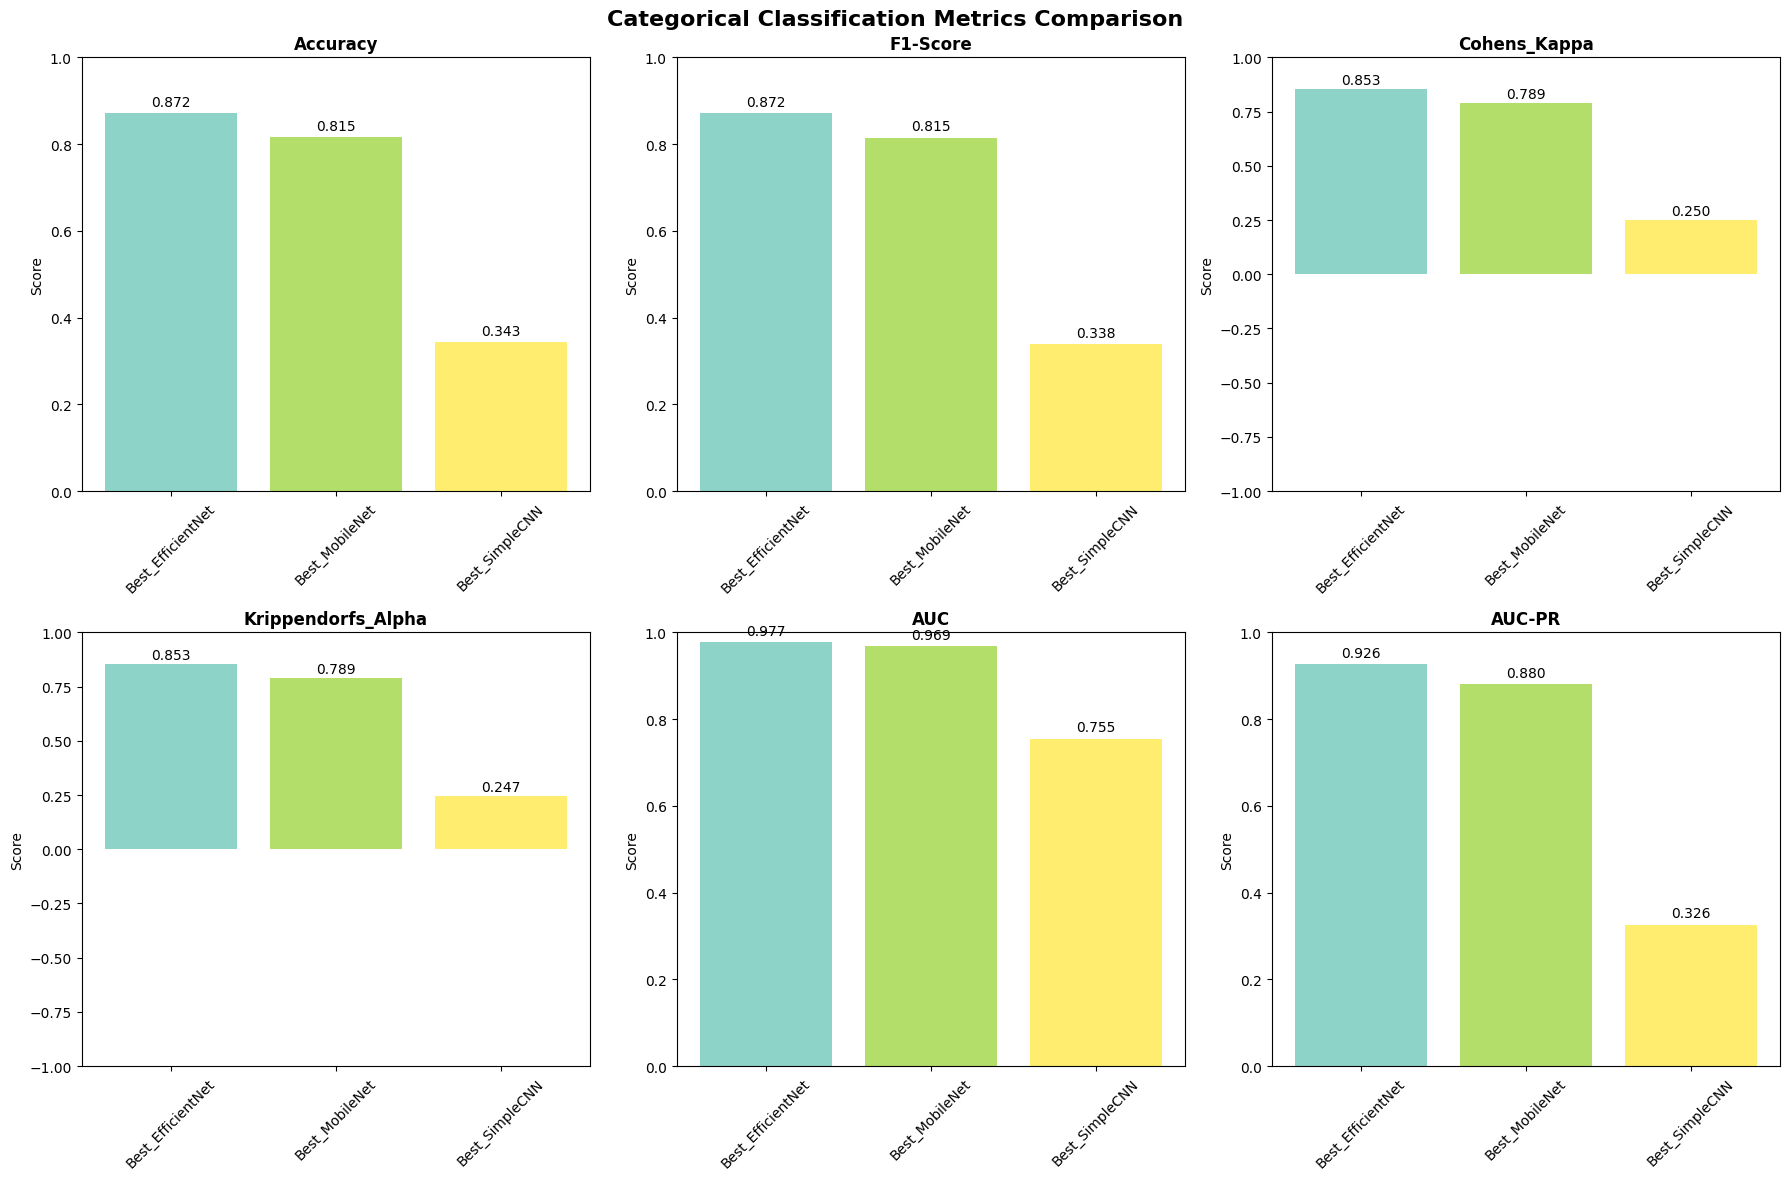

In [104]:
if results:
    # Categorical metrics comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Categorical Classification Metrics Comparison', fontsize=16, fontweight='bold')
    
    categorical_metrics = ['Accuracy', 'F1-Score', 'Cohens_Kappa', 'Krippendorfs_Alpha', 'AUC', 'AUC-PR']
    
    for idx, metric in enumerate(categorical_metrics):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        models = results_df['Model'].tolist()
        values = results_df[metric].tolist()
        
        bars = ax.bar(models, values, color=plt.cm.Set3(np.linspace(0, 1, len(models))))
        ax.set_title(f'{metric}', fontweight='bold')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10)
        
        # Set y-limits based on metric type
        if metric in ['Accuracy', 'F1-Score', 'AUC', 'AUC-PR']:
            ax.set_ylim(0, 1)
        elif metric in ['Cohens_Kappa', 'Krippendorfs_Alpha']:
            ax.set_ylim(-1, 1)
    
    plt.tight_layout()
    plt.savefig('categorical_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. Visualization - Continuous Metrics Comparison

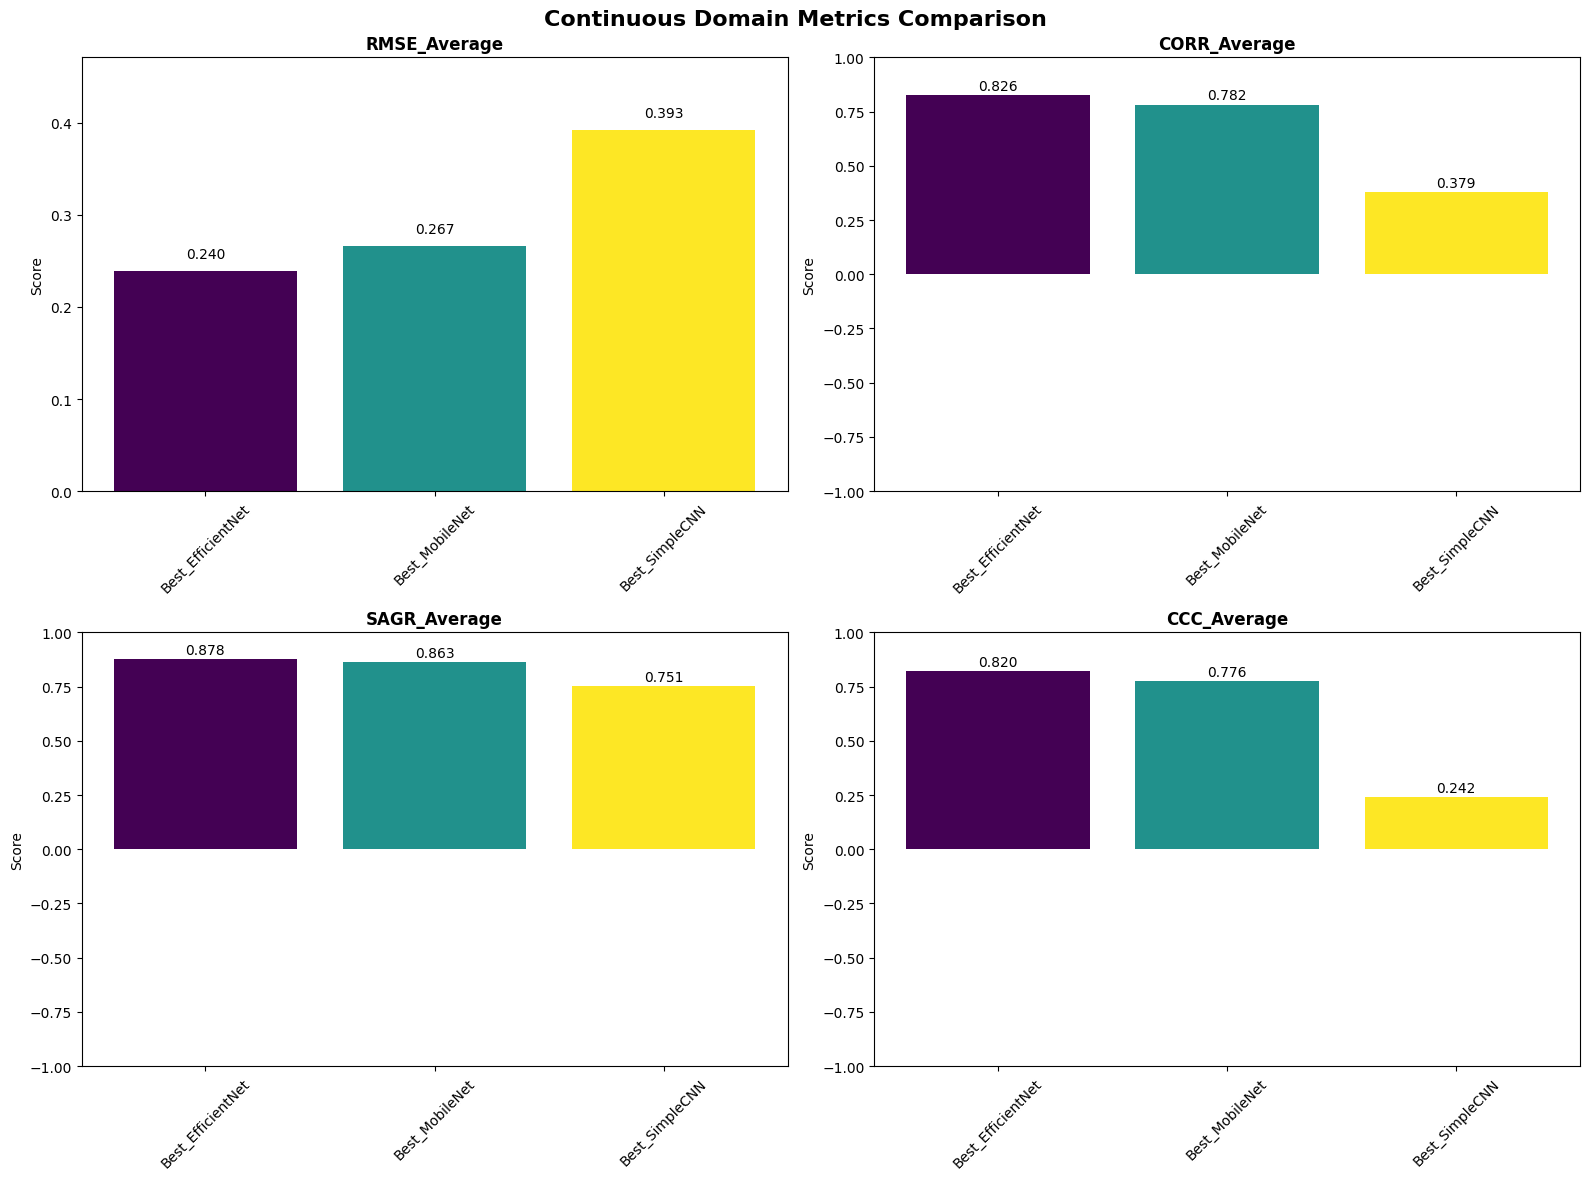

In [105]:
if results:
    # Continuous metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Continuous Domain Metrics Comparison', fontsize=16, fontweight='bold')
    
    continuous_metrics = ['RMSE_Average', 'CORR_Average', 'SAGR_Average', 'CCC_Average']
    
    for idx, metric in enumerate(continuous_metrics):
        row, col = idx // 2, idx % 2
        ax = axes[row, col]
        
        models = results_df['Model'].tolist()
        values = results_df[metric].tolist()
        
        bars = ax.bar(models, values, color=plt.cm.viridis(np.linspace(0, 1, len(models))))
        ax.set_title(f'{metric}', fontweight='bold')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.01),
                   f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=10)
        
        # Set appropriate y-limits
        if metric == 'RMSE_Average':
            ax.set_ylim(0, max(values) * 1.2)
        else:  # CORR, SAGR, CCC can range from -1 to 1
            ax.set_ylim(-1, 1)
    
    plt.tight_layout()
    plt.savefig('continuous_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## 12. Detailed Valence and Arousal Metrics Comparison

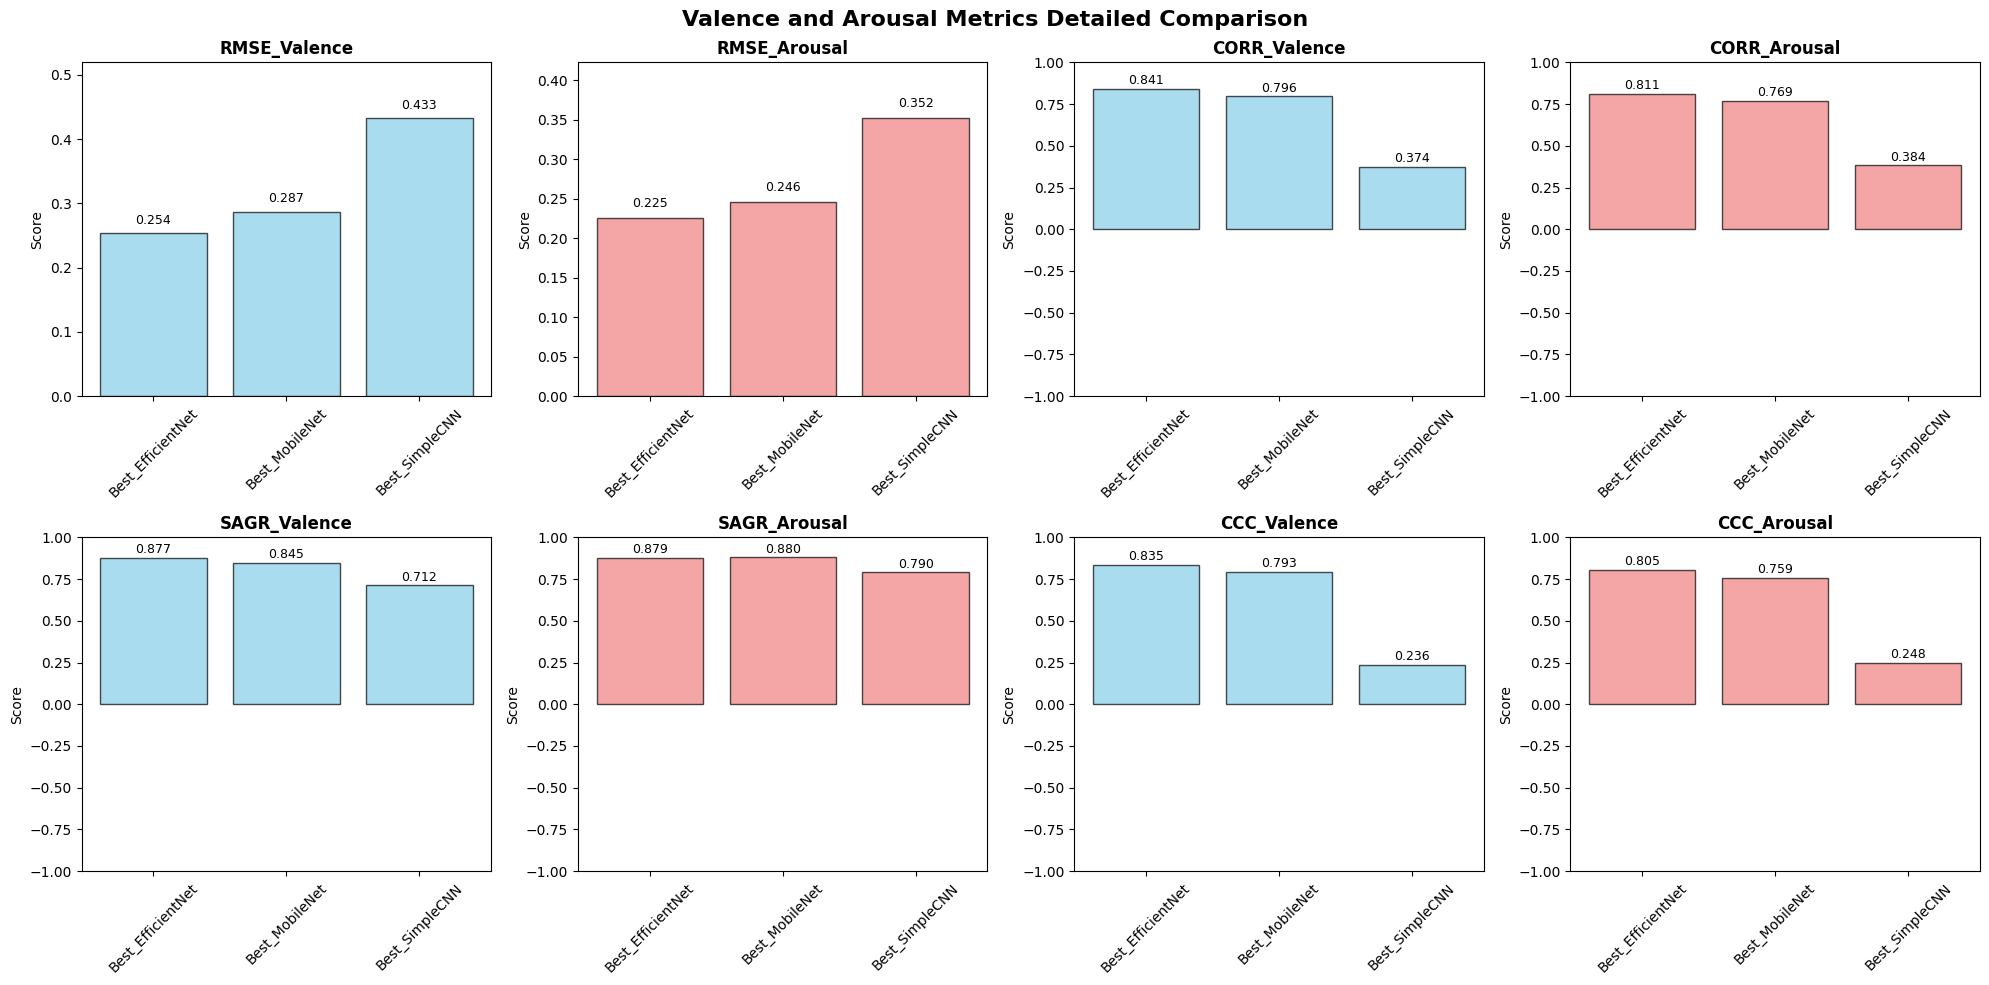

In [106]:
if results:
    # Detailed valence and arousal comparison
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Valence and Arousal Metrics Detailed Comparison', fontsize=16, fontweight='bold')
    
    val_aro_metrics = ['RMSE_Valence', 'RMSE_Arousal', 'CORR_Valence', 'CORR_Arousal', 
                       'SAGR_Valence', 'SAGR_Arousal', 'CCC_Valence', 'CCC_Arousal']
    
    for idx, metric in enumerate(val_aro_metrics):
        row, col = idx // 4, idx % 4
        ax = axes[row, col]
        
        models = results_df['Model'].tolist()
        values = results_df[metric].tolist()
        
        # Color by valence (blue) or arousal (red)
        colors = ['skyblue' if 'Valence' in metric else 'lightcoral'] * len(models)
        
        bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black')
        ax.set_title(f'{metric}', fontweight='bold')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.01),
                   f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)
        
        # Set appropriate y-limits
        if 'RMSE' in metric:
            ax.set_ylim(0, max(values) * 1.2)
        else:
            ax.set_ylim(-1, 1)
    
    plt.tight_layout()
    plt.savefig('valence_arousal_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## 13. Confusion Matrices for All Models

AttributeError: 'numpy.ndarray' object has no attribute 'spines'

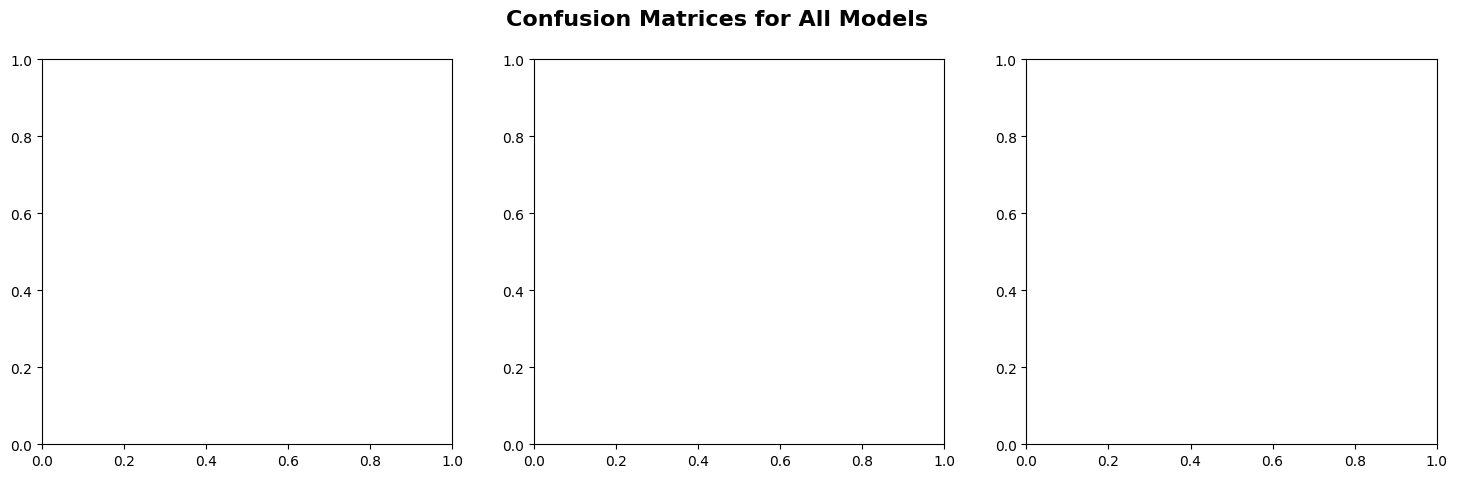

In [107]:
if results:
    num_models = len(results)
    cols = min(3, num_models)
    rows = (num_models + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if num_models == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')
    
    for idx, (model_name, result) in enumerate(results.items()):
        row, col = idx // cols, idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        
        preds = result['predictions']
        cm = confusion_matrix(preds['cls_targets'], preds['cls_preds'])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)],
                    yticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)])
        
        ax.set_title(f'{model_name}\nAccuracy: {result["categorical_metrics"]["Accuracy"]:.3f}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    # Hide unused subplots
    for idx in range(num_models, rows * cols):
        if rows > 1:
            row, col = idx // cols, idx % cols
            axes[row, col].set_visible(False)
        elif cols > 1:
            axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

## 14. Performance Ranking and Summary

In [ ]:
if results:
    print("\n" + "="*80)
    print("MODEL PERFORMANCE RANKING AND SUMMARY")
    print("="*80)
    
    # Create ranking for different metrics
    metrics_for_ranking = {
        'Overall Performance (Accuracy)': 'Accuracy',
        'Classification Quality (F1-Score)': 'F1-Score',
        'Agreement (Cohens Kappa)': 'Cohens_Kappa',
        'Reliability (Krippendorfs Alpha)': 'Krippendorfs_Alpha',
        'ROC Performance (AUC)': 'AUC',
        'Precision-Recall (AUC-PR)': 'AUC-PR',
        'Regression Error (RMSE Average)': 'RMSE_Average',
        'Correlation (CORR Average)': 'CORR_Average',
        'Sign Agreement (SAGR Average)': 'SAGR_Average',
        'Concordance (CCC Average)': 'CCC_Average'
    }
    
    rankings = {}
    
    for metric_name, metric_col in metrics_for_ranking.items():
        if metric_col == 'RMSE_Average':
            # For RMSE, lower is better
            sorted_df = results_df.sort_values(metric_col, ascending=True)
        else:
            # For other metrics, higher is better
            sorted_df = results_df.sort_values(metric_col, ascending=False)
        
        rankings[metric_name] = list(zip(sorted_df['Model'], sorted_df[metric_col]))
        
        print(f"\n🏆 {metric_name}:")
        print("-" * len(metric_name))
        for rank, (model, score) in enumerate(rankings[metric_name], 1):
            print(f"{rank:2d}. {model:<20} {score:8.4f}")
    
    # Overall best model (based on multiple criteria)
    print(f"\n{'='*50}")
    print("OVERALL BEST MODEL ANALYSIS")
    print('='*50)
    
    # Calculate weighted score for overall ranking
    weights = {
        'Accuracy': 0.2,
        'F1-Score': 0.15,
        'Cohens_Kappa': 0.1,
        'AUC': 0.1,
        'RMSE_Average': -0.15,  # Negative because lower is better
        'CORR_Average': 0.15,
        'CCC_Average': 0.15
    }
    
    overall_scores = {}
    for model_name in results_df['Model']:
        score = 0
        model_row = results_df[results_df['Model'] == model_name].iloc[0]
        
        for metric, weight in weights.items():
            if metric == 'RMSE_Average':
                # Normalize RMSE (lower is better, so we subtract from max)
                max_rmse = results_df[metric].max()
                normalized_score = (max_rmse - model_row[metric]) / max_rmse
                score += weight * normalized_score
            else:
                # For other metrics, normalize to 0-1 scale
                min_val = results_df[metric].min()
                max_val = results_df[metric].max()
                if max_val > min_val:
                    normalized_score = (model_row[metric] - min_val) / (max_val - min_val)
                else:
                    normalized_score = 1.0
                score += weight * normalized_score
        
        overall_scores[model_name] = score
    
    # Sort by overall score
    sorted_models = sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)
    
    print("Weighted Overall Ranking:")
    for rank, (model, score) in enumerate(sorted_models, 1):
        print(f"{rank}. {model}: {score:.4f}")
    
    best_model = sorted_models[0][0]
    print(f"\n🥇 BEST OVERALL MODEL: {best_model}")
    
    # Show detailed performance of best model
    best_result = results[best_model]
    print(f"\nDetailed Performance of {best_model}:")
    print("-" * 40)
    print("Categorical Metrics:")
    for metric, value in best_result['categorical_metrics'].items():
        print(f"  {metric:<20}: {value:8.4f}")
    
    print("\nContinuous Metrics:")
    for metric, value in best_result['continuous_metrics'].items():
        print(f"  {metric:<20}: {value:8.4f}")

## 15. Scatter Plots for Continuous Predictions

In [ ]:
if results:
    num_models = len(results)
    
    # Valence predictions scatter plot
    fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))
    if num_models == 1:
        axes = [axes]
    
    fig.suptitle('Valence Predictions vs Ground Truth', fontsize=16, fontweight='bold')
    
    for idx, (model_name, result) in enumerate(results.items()):
        ax = axes[idx]
        preds = result['predictions']
        
        val_true = preds['reg_targets'][:, 0]
        val_pred = preds['reg_preds'][:, 0]
        
        ax.scatter(val_true, val_pred, alpha=0.6, s=20)
        ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.8)  # Perfect prediction line
        ax.set_xlabel('True Valence')
        ax.set_ylabel('Predicted Valence')
        ax.set_title(f'{model_name}\nCORR: {result["continuous_metrics"]["CORR_Valence"]:.3f}')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('valence_scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Arousal predictions scatter plot
    fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))
    if num_models == 1:
        axes = [axes]
    
    fig.suptitle('Arousal Predictions vs Ground Truth', fontsize=16, fontweight='bold')
    
    for idx, (model_name, result) in enumerate(results.items()):
        ax = axes[idx]
        preds = result['predictions']
        
        aro_true = preds['reg_targets'][:, 1]
        aro_pred = preds['reg_preds'][:, 1]
        
        ax.scatter(aro_true, aro_pred, alpha=0.6, s=20, color='orange')
        ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.8)  # Perfect prediction line
        ax.set_xlabel('True Arousal')
        ax.set_ylabel('Predicted Arousal')
        ax.set_title(f'{model_name}\nCORR: {result["continuous_metrics"]["CORR_Arousal"]:.3f}')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('arousal_scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## 16. ROC Curves for Multi-class Classification

In [ ]:
if results and len(results) > 0:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    from itertools import cycle
    
    # Plot ROC curves for each model
    num_models = len(results)
    fig, axes = plt.subplots(1, num_models, figsize=(8*num_models, 6))
    if num_models == 1:
        axes = [axes]
    
    fig.suptitle('ROC Curves for Multi-class Classification', fontsize=16, fontweight='bold')
    
    for idx, (model_name, result) in enumerate(results.items()):
        ax = axes[idx]
        preds = result['predictions']
        
        # Binarize the output
        y_true_bin = label_binarize(preds['cls_targets'], classes=range(config.NUM_CLASSES))
        y_score = preds['cls_probs']
        
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(config.NUM_CLASSES):
            if np.sum(y_true_bin[:, i]) > 0:  # Only if class exists in test set
                fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot ROC curves
        colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'pink'])
        for i, color in zip(range(config.NUM_CLASSES), colors):
            if i in roc_auc:
                ax.plot(fpr[i], tpr[i], color=color, lw=2,
                       label=f'{config.EXPRESSION_LABELS[i]} (AUC = {roc_auc[i]:.3f})')
        
        ax.plot([0, 1], [0, 1], 'k--', lw=2)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves - {model_name}')
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

## 17. Final Summary and Recommendations

In [ ]:
if results:
    print("\n" + "="*100)
    print("FINAL SUMMARY AND RECOMMENDATIONS")
    print("="*100)
    
    print(f"\n📊 EVALUATION COMPLETED FOR {len(results)} MODEL(S)")
    print("-" * 50)
    
    for model_name in results.keys():
        print(f"✓ {model_name}")
    
    if len(results) > 1:
        best_model = sorted_models[0][0]
        print(f"\n🏆 BEST PERFORMING MODEL: {best_model}")
        print(f"   Overall weighted score: {sorted_models[0][1]:.4f}")
    
    print(f"\n📁 FILES GENERATED:")
    print("- model_comparison_results.csv")
    print("- categorical_metrics_comparison.png")
    print("- continuous_metrics_comparison.png") 
    print("- valence_arousal_metrics_comparison.png")
    print("- all_confusion_matrices.png")
    print("- valence_scatter_plots.png")
    print("- arousal_scatter_plots.png")
    print("- roc_curves.png")
    
    print(f"\n💡 KEY INSIGHTS:")
    
    if len(results) == 1:
        model_name = list(results.keys())[0]
        result = results[model_name]
        acc = result['categorical_metrics']['Accuracy']
        f1 = result['categorical_metrics']['F1-Score']
        rmse = result['continuous_metrics']['RMSE_Average']
        ccc = result['continuous_metrics']['CCC_Average']
        
        print(f"- {model_name} achieved {acc:.3f} accuracy and {f1:.3f} F1-score")
        print(f"- Regression performance: RMSE={rmse:.3f}, CCC={ccc:.3f}")
        
        if acc < 0.5:
            print("- Classification performance is below random chance - consider:")
            print("  * Using transfer learning with pre-trained models")
            print("  * Increasing model capacity")
            print("  * Better data augmentation")
            print("  * Class balancing techniques")
        
        if rmse > 0.5:
            print("- Regression performance needs improvement - consider:")
            print("  * Multi-task loss reweighting")
            print("  * Separate regression head optimization")
            print("  * Data normalization strategies")
    
    else:
        # Compare multiple models
        accuracies = [results[m]['categorical_metrics']['Accuracy'] for m in results.keys()]
        f1_scores = [results[m]['categorical_metrics']['F1-Score'] for m in results.keys()]
        
        best_acc_model = max(results.keys(), key=lambda x: results[x]['categorical_metrics']['Accuracy'])
        best_f1_model = max(results.keys(), key=lambda x: results[x]['categorical_metrics']['F1-Score'])
        
        print(f"- Best accuracy: {best_acc_model} ({results[best_acc_model]['categorical_metrics']['Accuracy']:.3f})")
        print(f"- Best F1-score: {best_f1_model} ({results[best_f1_model]['categorical_metrics']['F1-Score']:.3f})")
        print(f"- Performance gap: {max(accuracies) - min(accuracies):.3f} in accuracy")
    
    print(f"\n📋 METRICS EXPLANATION:")
    print("Categorical Metrics:")
    print("- Accuracy: Overall correct predictions ratio")
    print("- F1-Score: Harmonic mean of precision and recall") 
    print("- Cohen's Kappa: Agreement correcting for chance")
    print("- Krippendorff's Alpha: Reliability measure")
    print("- AUC: Area under ROC curve")
    print("- AUC-PR: Area under Precision-Recall curve")
    
    print("\nContinuous Metrics:")
    print("- RMSE: Root Mean Square Error (lower is better)")
    print("- CORR: Pearson correlation coefficient")
    print("- SAGR: Sign Agreement Rate")  
    print("- CCC: Concordance Correlation Coefficient (best overall metric)")
    
    print(f"\n🎯 RECOMMENDATIONS FOR FUTURE WORK:")
    print("1. Implement transfer learning with emotion-specific pre-trained models")
    print("2. Use ensemble methods to combine multiple model predictions")
    print("3. Apply advanced data augmentation and class balancing")
    print("4. Consider attention mechanisms for better feature learning")
    print("5. Experiment with different loss functions and optimization strategies")
    
else:
    print("No models were successfully evaluated. Please check your model paths and files.")

print("\n" + "="*100)
print("EVALUATION COMPLETED!")
print("="*100)

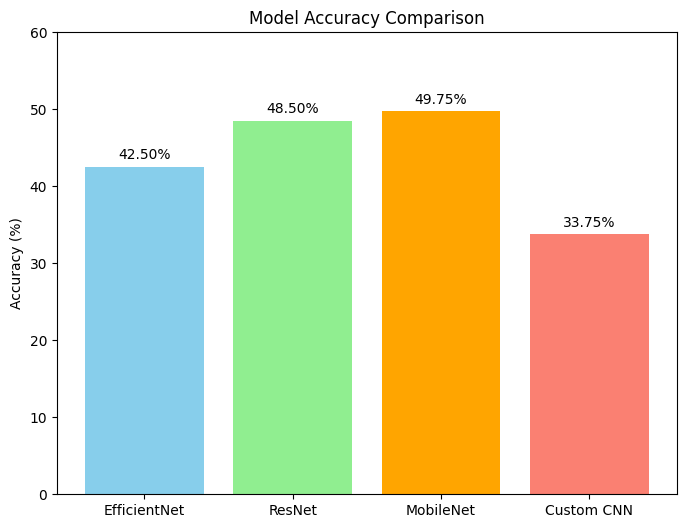

In [1]:
import matplotlib.pyplot as plt

# Model names and accuracies
models = ["EfficientNet", "ResNet", "MobileNet", "Custom CNN"]
accuracies = [42.5, 48.5, 49.75, 33.75]

# Plot bar chart
plt.figure(figsize=(8,6))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'orange', 'salmon'])

# Add labels and title
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 60)

# Annotate bars with accuracy values
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontsize=10)

plt.show()
